In [1]:
# import python library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# Upload Dataset form Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Dataset
df_full = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/Titanic.csv')

In [4]:
df_full

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df_full['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

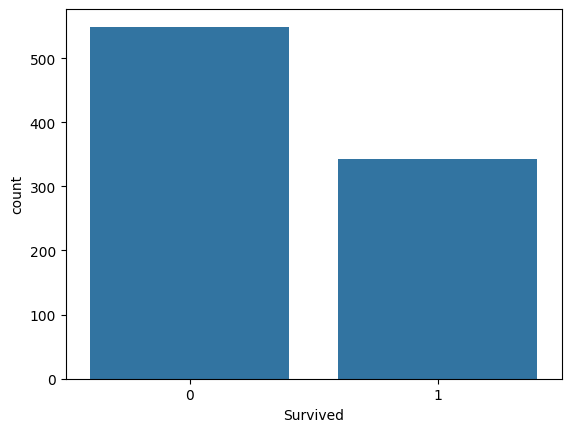

In [7]:
# Plot Target Feature
sns.countplot(x='Survived', data=df_full)
plt.show()

In [8]:
df_full.duplicated().sum()

0

In [9]:
df_full.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df_full.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
# Filled up missing value with the median
Age = df_full['Age'].fillna(value = df_full['Age'].median())

In [12]:
Age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [13]:
# Drop unnecessary features
df_drop = df_full.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age'], axis=1, inplace=True)

In [14]:
df_full

,Survived,Pclass,Sex
0,0,3,male
1,1,1,female
2,1,3,female
3,1,1,female
4,0,3,male
...,...,...,...
886,0,2,male
887,1,1,female
888,0,3,female
889,1,1,male


In [15]:
# Concate Age with filled values
df = pd.concat([df_full, Age], axis=1)

In [16]:
# Apply One Hot Encoder for Sex feature
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse=False, dtype=np.int32)

In [17]:
df_ohe = ohe.fit_transform(df[['Sex']])

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [18]:
# Show all features value with Encoded value in an array
np.hstack((df[['Survived', 'Pclass', 'Age']].values, df_ohe))

array([[ 0.,  3., 22.,  1.],
       [ 1.,  1., 38.,  0.],
       [ 1.,  3., 26.,  0.],
       ...,
       [ 0.,  3., 28.,  0.],
       [ 1.,  1., 26.,  1.],
       [ 0.,  3., 32.,  1.]])

In [19]:
# Convert array to dataframe and rename Sex column to gender
Gender = pd.DataFrame(df_ohe, columns=['Gender'])
Gender.head(5)

,Gender
0,1
1,0
2,0
3,0
4,1


In [20]:
# Concate gender column and drop sex column
dataset = pd.concat([df,Gender], axis=1).drop(columns=['Sex'])
dataset

,Survived,Pclass,Age,Gender
0,0,3,22.0,1
1,1,1,38.0,0
2,1,3,26.0,0
3,1,1,35.0,0
4,0,3,35.0,1
...,...,...,...,...
886,0,2,27.0,1
887,1,1,19.0,0
888,0,3,28.0,0
889,1,1,26.0,1


In [21]:
# Rename dataset to df
df = dataset
df

,Survived,Pclass,Age,Gender
0,0,3,22.0,1
1,1,1,38.0,0
2,1,3,26.0,0
3,1,1,35.0,0
4,0,3,35.0,1
...,...,...,...,...
886,0,2,27.0,1
887,1,1,19.0,0
888,0,3,28.0,0
889,1,1,26.0,1


In [22]:
# Define input and output/target features
X = df.drop(['Survived'], axis=1)
y = df['Survived']

In [23]:
# Apply Scaler for input/independent features
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [24]:
# Scale input/independent features
X_scale = scale.fit_transform(X)
X_scale

array([[ 0.82737724, -0.56573646,  0.73769513],
       [-1.56610693,  0.66386103, -1.35557354],
       [ 0.82737724, -0.25833709, -1.35557354],
       ...,
       [ 0.82737724, -0.1046374 , -1.35557354],
       [-1.56610693, -0.25833709,  0.73769513],
       [ 0.82737724,  0.20276197,  0.73769513]])

In [25]:
# Apply SMOTE on X and y
from imblearn.over_sampling import SMOTE
smote = SMOTE()

In [26]:
X_resampled, y_resampled = smote.fit_resample(X_scale, y)

In [27]:
# Apply PCA for column reduction
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)

In [28]:
X_pca = pca.fit_transform(X_scale)
X_resampled_pca = pca.transform(X_resampled)

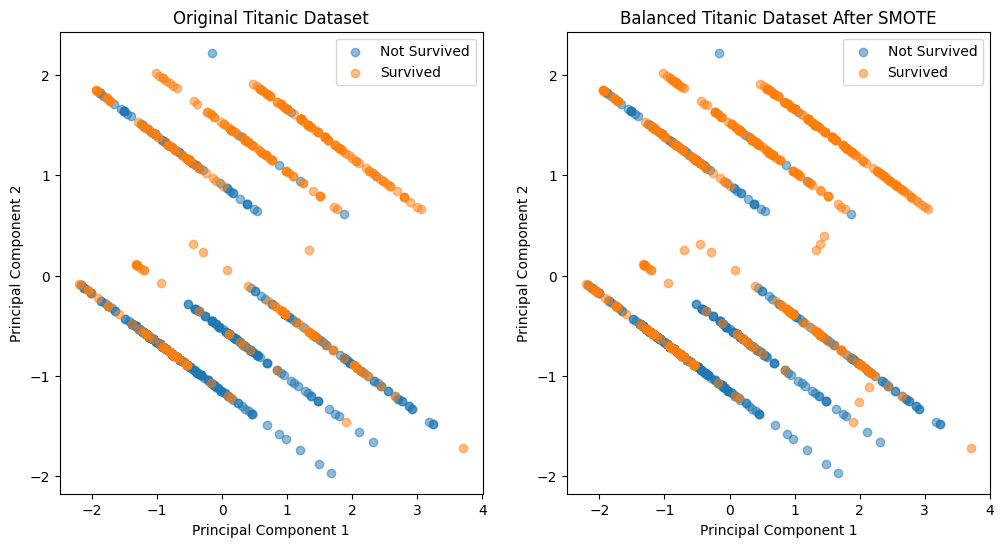

In [29]:
# Apply Scatter plot for visualize data
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], label='Not Survived', alpha=0.5)
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], label='Survived', alpha=0.5)
plt.title('Original Titanic Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_resampled_pca[y_resampled == 0, 0], X_resampled_pca[y_resampled == 0, 1], label='Not Survived', alpha=0.5)
plt.scatter(X_resampled_pca[y_resampled == 1, 0], X_resampled_pca[y_resampled == 1, 1], label='Survived', alpha=0.5)
plt.title('Balanced Titanic Dataset After SMOTE')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()


In [30]:
list(y).count(1), list(y_resampled).count(1)

(342, 549)

In [31]:
# Split train and test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scale, y, test_size=0.2, random_state=42)

In [32]:
# Apply SMOTE on Train and Test Data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [33]:
list(y_train).count(1), list(y_resampled).count(1)

(268, 444)

In [34]:
# Apply KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

In [35]:
# Observe KNN performance and pick the best performed K value
accuracy_train_list = []
accuracy_test_list  = []
f1_train_list       = []
f1_test_list        = []

for i in range(3, 13):
  print('k', i)

  KNN = KNeighborsClassifier(n_neighbors=i)
  KNN.fit(X_resampled, y_resampled)

  y_pred_train        = KNN.predict(X_train)

  accuracy_train      = accuracy_score(y_pred_train, y_train)
  accuracy_train_list.append(accuracy_train)

  f1_train = f1_score(y_pred_train, y_train)
  f1_train_list.append(f1_train)



  y_pred_test = KNN.predict(X_test)

  accuracy_test = accuracy_score(y_pred_test, y_test)
  accuracy_test_list.append(accuracy_test)

  f1_test = f1_score(y_pred_test, y_test)
  f1_test_list.append(f1_test)

  print(accuracy_train, accuracy_test)
  print(f1_train, f1_test, '\n')

k 3
0.8426966292134831 0.8044692737430168
0.7971014492753623 0.7712418300653594 

k 4
0.8426966292134831 0.8156424581005587
0.7837837837837839 0.7724137931034482 

k 5
0.8216292134831461 0.7932960893854749
0.7843803056027164 0.7701863354037266 

k 6
0.8412921348314607 0.7932960893854749
0.7679671457905545 0.7338129496402878 

k 7
0.8300561797752809 0.7932960893854749
0.7659574468085107 0.7375886524822697 

k 8
0.8384831460674157 0.776536312849162
0.7578947368421053 0.7058823529411764 

k 9
0.8342696629213483 0.7877094972067039
0.7686274509803922 0.7323943661971832 

k 10
0.8258426966292135 0.776536312849162
0.751004016064257 0.7058823529411764 

k 11
0.8258426966292135 0.770949720670391
0.7642585551330798 0.7132867132867132 

k 12
0.8286516853932584 0.7821229050279329
0.7530364372469635 0.711111111111111 



<ipython-input-36-4eca0d1b8dee>:4: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#controlling-the-legend-entries
  plt.legend('Train', 'Test')


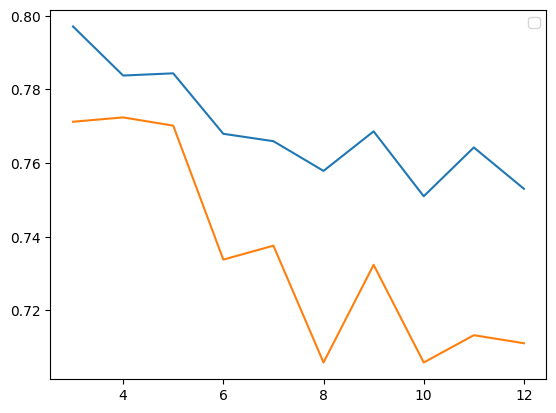

In [36]:
# Plot on KNN result
plt.plot(list(range(3, 13)),f1_train_list)
plt.plot(list(range(3, 13)),f1_test_list)
plt.legend('Train', 'Test')
plt.show()

In [37]:
# Apply KNN on best performed K value
KNN = KNeighborsClassifier(n_neighbors=4)
KNN.fit(X_train, y_train)

y_pred_train = KNN.predict(X_train)
accuracy_train = accuracy_score(y_pred_train, y_train)
f1_train = f1_score(y_pred_train, y_train)

y_pred_test = KNN.predict(X_test)
accuracy_test = accuracy_score(y_pred_test, y_test)
f1_test = f1_score(y_pred_test, y_test)

In [38]:
# Apply Classification Report
from sklearn.metrics import classification_report
target_names = ['Survived', 'Not Survived']

In [39]:
# Show the over all performance on train data
print('Train Data of KNN: ','\n')
print('Accuracy on Train Data: ', accuracy_train, '\n')
print('F1_Score on Train Data: ', f1_train, '\n')
print('Classification Report on Train Data: ', '\n', '\n', classification_report(y_pred_train, y_train, target_names=target_names))

Train Data of KNN:  

Accuracy on Train Data:  0.8426966292134831 

F1_Score on Train Data:  0.7803921568627451 

Classification Report on Train Data:  
 
               precision    recall  f1-score   support

    Survived       0.90      0.85      0.88       470
Not Survived       0.74      0.82      0.78       242

    accuracy                           0.84       712
   macro avg       0.82      0.84      0.83       712
weighted avg       0.85      0.84      0.84       712



In [40]:
# Show the over all performance on test data
print('Test Data of KNN: ','\n')
print('Accuracy on Test Data: ', accuracy_test, '\n' )
print('F1 Score on Test Data: ', f1_test, '\n')
print('Classification Report on Test Data: ', '\n','\n', classification_report(y_pred_test, y_test))

Test Data of KNN:  

Accuracy on Test Data:  0.7988826815642458 

F1 Score on Test Data:  0.7428571428571429 

Classification Report on Test Data:  
 
               precision    recall  f1-score   support

           0       0.87      0.81      0.83       113
           1       0.70      0.79      0.74        66

    accuracy                           0.80       179
   macro avg       0.78      0.80      0.79       179
weighted avg       0.81      0.80      0.80       179



In [41]:
# Apply Confusion Matrix
from sklearn.metrics import confusion_matrix
c_train = confusion_matrix(y_pred_train, y_train)
c_test  = confusion_matrix(y_pred_test, y_test)

In [42]:
# Results of Confusion Matrix on train and test data
print('Confusion Matrix on Train Data: ','\n', c_train, '\n')
print('Confusion Matrix on Test  Data: ', '\n', c_test)

Confusion Matrix on Train Data:  
 [[401  69]
 [ 43 199]] 

Confusion Matrix on Test  Data:  
 [[91 22]
 [14 52]]


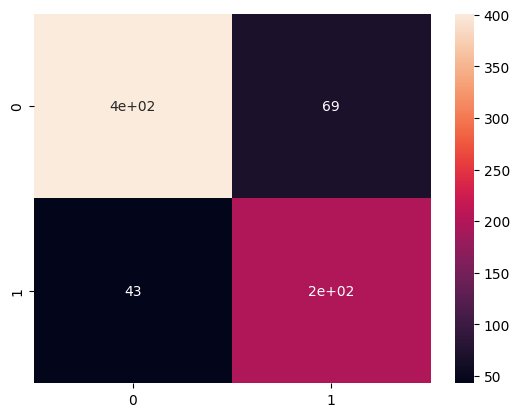

In [43]:
# Apply heatmap on train Data
sns.heatmap(c_train, annot=True)
plt.show()

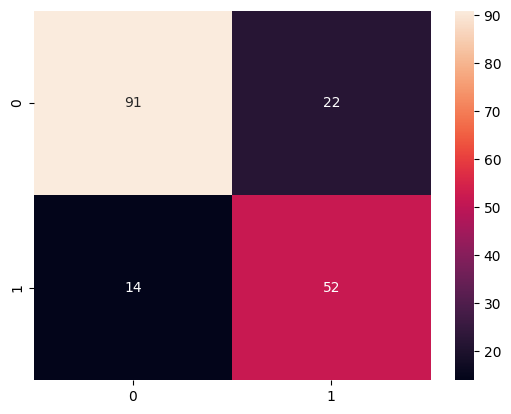

In [44]:
# Apply heatmap on test Data
sns.heatmap(c_test, annot=True)
plt.show()